# Bike-Sharing Hourly Demand Forecasting

**Predicting how many bikes a city bike-sharing system will rent each hour**, so the
operations team can position the fleet, schedule rebalancing trucks and staff
appropriately.

This notebook is the narrated, end-to-end version of the project. The reusable
logic lives in [`src/`](../src) - here we tell the story and show the evidence
behind each decision. The workflow follows eight steps:

1. **Frame** the problem
2. **Get** the data
3. **Temporal split** (hold out the most recent data)
4. **Explore** the data
5. **Engineer** features
6. **Shortlist** models
7. **Fine-tune** the best one
8. **Evaluate** honestly on the test set

> The headline result: a Gradient Boosting model with a **test RMSE of ~70
> bikes/hour** and an **R² of 0.90**, validated with proper time-series methodology.

## 0. Setup

The heavy lifting is imported from the project's `src/` package, so the notebook
stays focused on narrative and analysis rather than boilerplate.

In [1]:
import sys
from pathlib import Path

# Make the project's `src/` package importable from the notebooks/ folder.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline

from src.data import load_data, temporal_train_test_split, split_X_y
from src.features import build_preprocessing, add_time_features
from src.train import build_model, BEST_PARAMS
from src.evaluate import evaluate, error_by_segment

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
RANDOM_STATE = 42
print("Setup complete.")

Setup complete.


## 1. Frame the problem

A city bike-sharing operator needs to anticipate **hourly rental demand**.
Under-supply means lost rides and frustrated users; over-supply wastes operating
cost moving and storing idle bikes.

- **Task type:** supervised regression on a **time series**.
- **Target:** `cnt`, the number of bikes rented in a given hour.
- **Success metric:** **RMSE in bikes** - an absolute, operations-friendly error.
  Being off by 70 bikes means the same thing to a dispatcher whether demand is
  high or low, which is exactly the quantity they plan around.

## 2. Get the data

[UCI Bike Sharing Dataset](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset)
- hourly rentals for Washington D.C. across 2011-2012.

In [2]:
df = load_data()
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 17,379 rows x 17 columns


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.29,0.81,0.00,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.27,0.80,0.00,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.27,0.80,0.00,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.29,0.75,0.00,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.29,0.75,0.00,0,1,1


In [3]:
# The target: hourly rental count.
df["cnt"].describe()[["mean", "std", "min", "max"]]

mean   189.46
std    181.39
min      1.00
max    977.00
Name: cnt, dtype: float64

The target is **heavy-tailed**: most hours see modest demand, but rush hours
spike far above the mean (max 977 vs. mean ~190). A naive model that predicts the
average would be wrong by ~180 bikes on a typical busy hour - that is the bar to
beat.

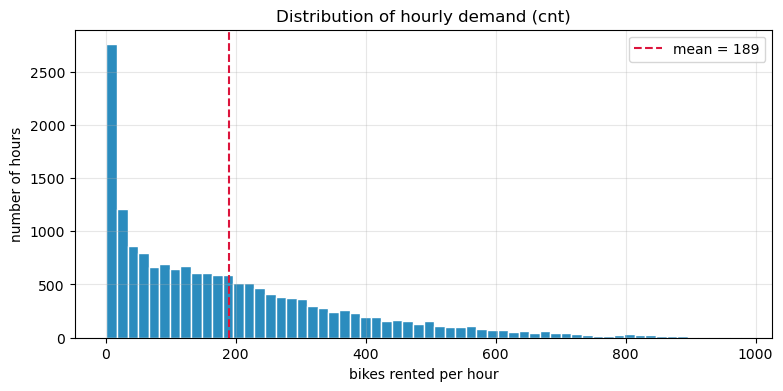

In [4]:
fig, ax = plt.subplots()
ax.hist(df["cnt"], bins=60, color="#2b8cbe", edgecolor="white")
ax.axvline(df["cnt"].mean(), color="crimson", linestyle="--", label=f"mean = {df['cnt'].mean():.0f}")
ax.set(title="Distribution of hourly demand (cnt)", xlabel="bikes rented per hour", ylabel="number of hours")
ax.legend()
plt.show()

## 3. Temporal split

Because this is a time series, the test set must be the **most recent** slice of
data. A random split would let the model "see the future" during training and
produce an over-optimistic, dishonest score.

We hold out the most recent **20%** of hours as the test set.

In [5]:
train_df, test_df = temporal_train_test_split(df, test_size=0.2)

print(f"Train: {len(train_df):,} rows | {train_df['dteday'].min()} -> {train_df['dteday'].max()}")
print(f"Test : {len(test_df):,} rows | {test_df['dteday'].min()} -> {test_df['dteday'].max()}")
print()
print(f"Mean demand  train: {train_df['cnt'].mean():.1f} bikes/hour")
print(f"Mean demand  test : {test_df['cnt'].mean():.1f} bikes/hour")
print(f"Growth train -> test: +{(test_df['cnt'].mean()/train_df['cnt'].mean()-1)*100:.0f}%")

Train: 13,904 rows | 2011-01-01 -> 2012-08-07
Test : 3,475 rows | 2012-08-07 -> 2012-12-31

Mean demand  train: 174.6 bikes/hour
Mean demand  test : 248.7 bikes/hour
Growth train -> test: +42%


This split surfaces a crucial fact: **average demand in the test period is ~40%
higher than in training.** The system grew. A model that ignores this trend (or a
baseline that predicts the historical average) is systematically biased low on the
test set - which is precisely why a good trend feature matters so much here.

## 4. Explore the data

We explore on the **training set only**, to avoid letting test-set patterns
influence our design choices.

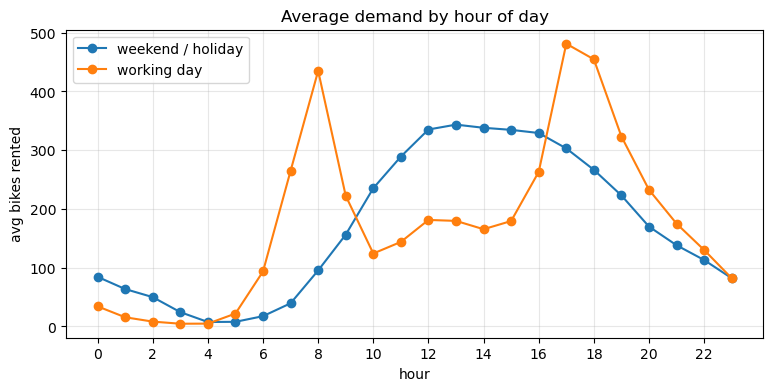

In [6]:
# Demand by hour of day, split by working day vs. weekend/holiday.
by_hour = train_df.groupby(["workingday", "hr"])["cnt"].mean().unstack(0)

fig, ax = plt.subplots()
ax.plot(by_hour.index, by_hour[0], marker="o", label="weekend / holiday")
ax.plot(by_hour.index, by_hour[1], marker="o", label="working day")
ax.set(title="Average demand by hour of day", xlabel="hour", ylabel="avg bikes rented", xticks=range(0, 24, 2))
ax.legend()
plt.show()

Two completely different demand shapes:

- **Working days** show sharp **commuter peaks** at ~8h and ~17-18h.
- **Weekends** show a single broad **leisure hump** around midday.

The hour of day is clearly the dominant driver - and its effect depends on whether
it's a working day. That insight motivates both the cyclical hour encoding and the
`is_workday_rush` feature.

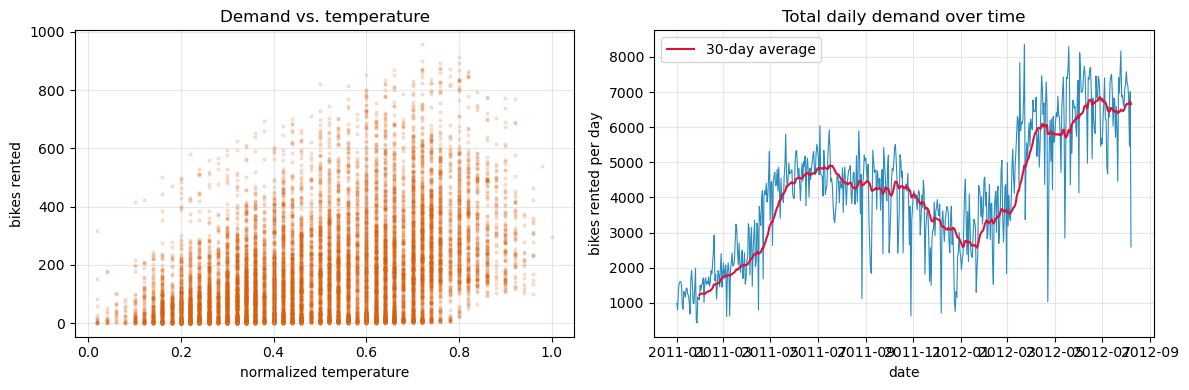

In [7]:
# Weather and the long-term growth trend.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(train_df["temp"], train_df["cnt"], s=4, alpha=0.15, color="#d95f0e")
axes[0].set(title="Demand vs. temperature", xlabel="normalized temperature", ylabel="bikes rented")

daily = train_df.groupby("dteday")["cnt"].sum()
daily.index = pd.to_datetime(daily.index)
axes[1].plot(daily.index, daily.values, color="#2b8cbe", linewidth=0.8)
axes[1].plot(daily.index, daily.rolling(30).mean(), color="crimson", label="30-day average")
axes[1].set(title="Total daily demand over time", xlabel="date", ylabel="bikes rented per day")
axes[1].legend()
plt.tight_layout()
plt.show()

- **Temperature** has a clear positive effect (warmer -> more rides), tapering at
  the extremes.
- The **30-day average rises steadily** across the two years: real system growth.
  This is what the `days_since_start` trend feature captures.

## 5. Engineer features

Two ideas drive the feature design (implemented in [`src/features.py`](../src/features.py)):

1. **Cyclical encoding.** Hour, month and weekday are *circular* - hour 23 is as
   close to hour 0 as hour 1 is. Encoding each as a `sin`/`cos` pair lets the model
   treat them as the continuous cycles they are.
2. **Domain features.** A working-day rush-hour flag, a midday flag, a long-term
   growth trend and a temperature/humidity "pleasantness" interaction.

In [8]:
# What add_time_features produces (a few engineered columns):
sample = add_time_features(train_df.head())
sample[["hr", "hr_sin", "hr_cos", "days_since_start", "is_workday_rush", "temp_x_hum"]]

,hr,hr_sin,hr_cos,days_since_start,is_workday_rush,temp_x_hum
0,0,0.00,1.00,0,0,0.05
1,1,0.26,0.97,0,0,0.04
2,2,0.50,0.87,0,0,0.04
3,3,0.71,0.71,0,0,0.06
4,4,0.87,0.50,0,0,0.06


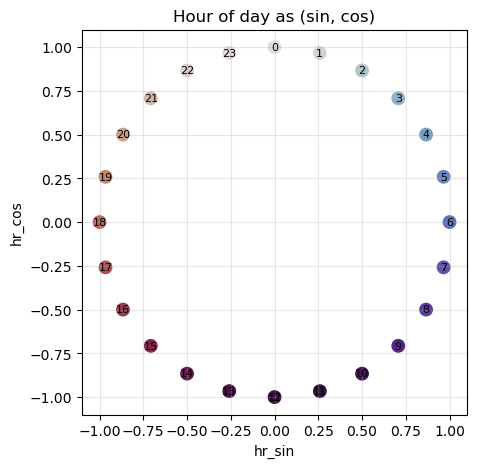

In [9]:
# Why cyclical encoding: the 24 hours map onto a circle, so adjacent hours
# (including 23 -> 0) are close in feature space.
hours = np.arange(24)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(np.sin(2*np.pi*hours/24), np.cos(2*np.pi*hours/24), c=hours, cmap="twilight", s=80)
for h in hours:
    ax.annotate(str(h), (np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24)), fontsize=8, ha="center", va="center")
ax.set(title="Hour of day as (sin, cos)", xlabel="hr_sin", ylabel="hr_cos")
ax.set_aspect("equal")
plt.show()

## 6. Preprocessing pipeline

All feature engineering, one-hot encoding and scaling live in a single
scikit-learn `Pipeline`. This matters for correctness: when wrapped in
cross-validation, **each fold is fitted only on its own training data**, so there
is no leakage from validation or test folds.

In [10]:
preprocessing = build_preprocessing()
X_train, y_train = split_X_y(train_df)
X_test,  y_test  = split_X_y(test_df)

X_train_prepared = preprocessing.fit_transform(X_train)
print(f"Raw features:        {X_train.shape[1]}")
print(f"Prepared features:   {X_train_prepared.shape[1]}")
print("Transformed feature names:")
print(list(preprocessing.named_steps['column_transformer'].get_feature_names_out()))

Raw features:        13
Prepared features:   24
Transformed feature names:
['cat__season_1', 'cat__season_2', 'cat__season_3', 'cat__season_4', 'cat__weathersit_1', 'cat__weathersit_2', 'cat__weathersit_3', 'cat__weathersit_4', 'pass__yr', 'pass__holiday', 'pass__workingday', 'pass__hr_sin', 'pass__hr_cos', 'pass__mnth_sin', 'pass__mnth_cos', 'pass__weekday_sin', 'pass__weekday_cos', 'pass__is_workday_rush', 'pass__is_workday_midday', 'pass__temp_x_hum', 'pass__temp', 'pass__hum', 'pass__windspeed', 'num__days_since_start']


## 7. Shortlist models

We compare four model families using **`TimeSeriesSplit`** cross-validation - the
cross-validation equivalent of our temporal split. Each fold trains on the past
and validates on the immediate future, never the reverse.

In [11]:
tscv = TimeSeriesSplit(n_splits=5)

candidates = {
    "Linear Regression": LinearRegression(),
    "Decision Tree":     DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest":     RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

rows = []
for name, est in candidates.items():
    pipe = Pipeline([("preprocessing", build_preprocessing()), ("model", est)])
    scores = cross_val_score(pipe, X_train, y_train, cv=tscv,
                             scoring="neg_root_mean_squared_error", n_jobs=-1)
    rows.append({"model": name, "cv_rmse": -scores.mean(), "cv_std": scores.std()})

shortlist = pd.DataFrame(rows).sort_values("cv_rmse").reset_index(drop=True)
shortlist

,model,cv_rmse,cv_std
0,Random Forest,74.80,15.33
1,Gradient Boosting,77.96,13.51
2,Decision Tree,94.92,14.07
3,Linear Regression,104.85,18.24


Tree ensembles clearly win. **Gradient Boosting** and **Random Forest** are the
two finalists; we take Gradient Boosting forward to tuning, where it has the most
head-room.

## 8. Fine-tune

The final hyperparameters were selected with `GridSearchCV` over the same
`TimeSeriesSplit`. The grid search is not re-run here (it is slow and already done);
the winning parameters are declared explicitly in
[`src/train.py`](../src/train.py) for full reproducibility. We confirm the tuned
cross-validated score below.

In [12]:
print("Best hyperparameters (from GridSearchCV):")
for k, v in BEST_PARAMS.items():
    print(f"  {k} = {v}")

tuned = build_model()  # preprocessing + GradientBoosting(**BEST_PARAMS)
tuned_scores = cross_val_score(tuned, X_train, y_train, cv=tscv,
                               scoring="neg_root_mean_squared_error", n_jobs=-1)
print(f"\nTuned Gradient Boosting  CV RMSE: {-tuned_scores.mean():.2f} bikes")

Best hyperparameters (from GridSearchCV):
  random_state = 42
  learning_rate = 0.02
  n_estimators = 800
  max_depth = 5
  min_samples_leaf = 10



Tuned Gradient Boosting  CV RMSE: 66.72 bikes


Tuning lowered the cross-validated RMSE from ~77 (default GB) to **~67 bikes**.
Expanding the grid further bought only ~1 additional bike of accuracy, so tuning
was stopped - diminishing returns.

**Decision recorded but rejected:** a `log(cnt)` target transform was tested. It
*worsened* the absolute RMSE, because it optimizes *relative* error while the
business metric is absolute, and the tree ensemble already handles the skewed
target well. We kept the raw target.

## 9. Train final model and evaluate on the test set

The test set has not influenced any decision up to this point, so this is a fair
estimate of real-world performance.

In [13]:
final_model = tuned.fit(X_train, y_train)
metrics = evaluate(final_model, X_test, y_test)

print("Test-set performance")
print("-" * 32)
print(f"RMSE      : {metrics['rmse']:.1f} bikes/hour")
print(f"RMSE 95%CI: [{metrics['rmse_ci_95'][0]:.1f}, {metrics['rmse_ci_95'][1]:.1f}]")
print(f"R^2       : {metrics['r2']:.3f}")
print(f"MAPE      : {metrics['mape']:.0f}%")

Test-set performance
--------------------------------
RMSE      : 70.0 bikes/hour
RMSE 95%CI: [66.7, 73.9]
R^2       : 0.899
MAPE      : 56%


In [14]:
# Baseline for context: predict the historical (training) mean for every hour.
baseline_pred = np.full(len(y_test), y_train.mean())
baseline_rmse = np.sqrt(np.mean((y_test - baseline_pred) ** 2))
improvement = (1 - metrics["rmse"] / baseline_rmse) * 100
print(f"Baseline RMSE (predict train mean): {baseline_rmse:.1f} bikes")
print(f"Model RMSE                        : {metrics['rmse']:.1f} bikes")
print(f"Improvement over baseline         : {improvement:.0f}%")

Baseline RMSE (predict train mean): 232.6 bikes
Model RMSE                        : 70.0 bikes
Improvement over baseline         : 70%


**The model explains 90% of the variance in hourly demand with an average error of
~70 bikes - a ~70% reduction over the naive baseline.** The baseline does so poorly
partly because of the growth trend: predicting the *training* average badly
under-shoots the higher-demand test period, which the model captures.

The cross-validated RMSE (~67) and the test RMSE (~70) are close, confirming the
model generalizes and is **not overfit** to the validation folds.

## 10. Error analysis - where is the model reliable?

A single global metric hides *where* the model is strong or weak. We break the
error down by segment.

In [15]:
y_pred = final_model.predict(X_test)

by_workday = error_by_segment(X_test, y_test, y_pred, "workingday")
by_workday.index = ["weekend / holiday", "working day"]
print("Error by day type:")
by_workday

Error by day type:


,rmse,mape,mean_demand,n
weekend / holiday,77.30,72.40,228.00,"1,127.00"
working day,66.20,47.70,258.70,"2,348.00"


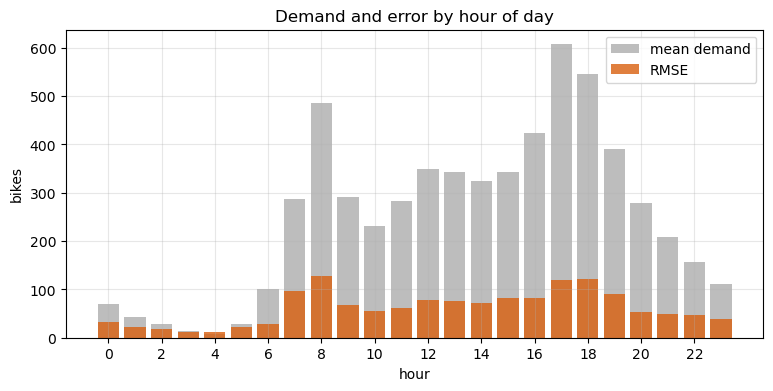

In [16]:
by_hour_err = error_by_segment(X_test, y_test, y_pred, "hr")

fig, ax = plt.subplots()
ax.bar(by_hour_err.index, by_hour_err["mean_demand"], color="#bdbdbd", label="mean demand")
ax.bar(by_hour_err.index, by_hour_err["rmse"], color="#d95f0e", alpha=0.8, label="RMSE")
ax.set(title="Demand and error by hour of day", xlabel="hour", ylabel="bikes", xticks=range(0, 24, 2))
ax.legend()
plt.show()

- The model is **more accurate on working days** (RMSE ~66) than weekends (~78):
  commuter patterns are more regular than leisure ones.
- Absolute error grows during **peak hours** simply because demand is large there -
  but in *relative* terms the peak is where the model is most reliable (~24% error).
- At **night**, the absolute error is tiny but the percentage error looks huge.
  This is why the global **MAPE (~56%) is misleading**: being off by 3 bikes when
  demand is 5 is a 60% error that means nothing operationally.

### What drives the predictions

Hour-of-day features (hr_sin + hr_cos) account for 44% of importance.



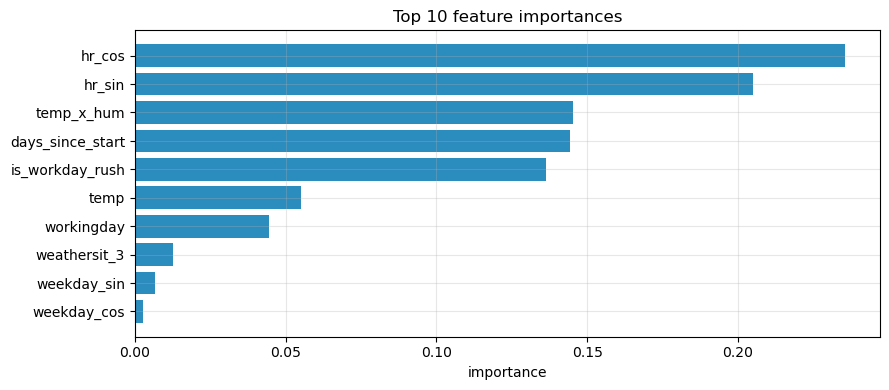

In [17]:
importances = final_model.named_steps["model"].feature_importances_
names = final_model.named_steps["preprocessing"].named_steps["column_transformer"].get_feature_names_out()
imp = pd.Series(importances, index=[n.split("__")[-1] for n in names]).sort_values(ascending=False)

hour_importance = imp[["hr_sin", "hr_cos"]].sum() * 100
print(f"Hour-of-day features (hr_sin + hr_cos) account for {hour_importance:.0f}% of importance.\n")

top = imp.head(10).sort_values()
fig, ax = plt.subplots()
ax.barh(top.index, top.values, color="#2b8cbe")
ax.set(title="Top 10 feature importances", xlabel="importance")
plt.tight_layout()
plt.show()

The ranking matches domain intuition: **hour of day dominates**, followed by the
weather interaction, the long-term growth trend and the rush-hour flag - exactly
the signals the exploration suggested.

## 11. Conclusions, limitations & next steps

**What we built.** An honest, well-validated hourly demand forecaster: **R² 0.90,
test RMSE ~70 bikes (95% CI 66.7-73.9), ~70% better than baseline**, with the
time-series methodology that makes those numbers trustworthy.

**Key decisions that made it correct, not just functional:**
- Temporal split + `TimeSeriesSplit` CV (no future leakage).
- Cyclical encoding of circular time variables.
- Domain features (rush-hour flag, weather interaction, growth trend).
- Absolute (RMSE) over relative (MAPE) metric, matched to the business need.
- Rejecting the `log` transform after testing it.

**Limitations:**
- **No special events** (festivals, games, closures) - human judgment should
  override the model on those days.
- **No lag features** - the model ignores the previous hour's/day's demand.
- **Weaker on weekends and night hours.**
- **Partial seasonal coverage** in the test window (summer is absent).

**Most promising next step:** add **lag features** (recent demand). In time-series
forecasting this is usually the single biggest lever, and it is the natural
follow-up to this baseline.